In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/processed/survey_v1.1.json"

with open(DATA_PATH) as f:
    data = json.load(f)

N = len(data)
print(f"Loaded {N} records, {len(data[0])} fields each.")

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Colour palette (one per section)
C_MEAS  = "#4C72B0"   # blue  – measures
C_BUILD = "#55A868"   # green – building
C_SOCIO = "#C44E52"   # red   – sociodemographics
C_TRIG  = "#DD8452"   # orange – triggers & subsidies

def pct_of(values, total=None):
    """Return list of percentages."""
    t = total or sum(values)
    return [v / t * 100 for v in values]

def get_field(field, cast=str):
    """Return non-null values of a field, cast to type."""
    return [cast(r[field]) for r in data if r.get(field) is not None]

Loaded 1651 records, 143 fields each.


---
## 3 · Sociodemographics

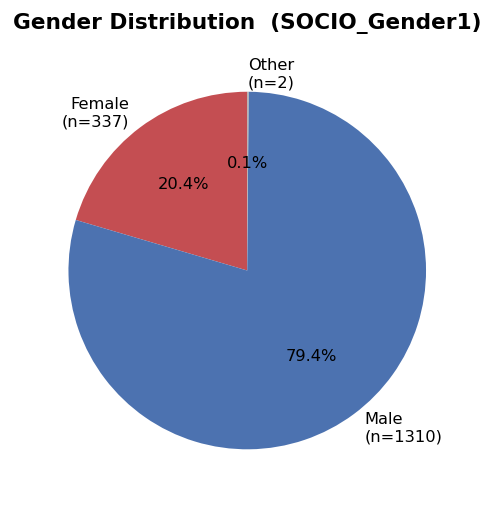

In [3]:
# ── 3a: Gender ────────────────────────────────────────────────────────────────
gender_map = {"1": "Female", "2": "Male", "3": "Other"}

g_raw    = Counter(get_field("SOCIO_Gender1"))
g_keys   = sorted(g_raw, key=int)
g_vals   = [g_raw[k] for k in g_keys]
g_labels = [f"{gender_map[k]}\n(n={g_raw[k]})" for k in g_keys]

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.pie(g_vals, labels=g_labels, autopct="%1.1f%%",
       colors=[C_SOCIO, "#4C72B0", "#aaaaaa"], startangle=90,
       textprops={"fontsize": 9})
ax.set_title("Gender Distribution  (SOCIO_Gender1)", pad=10)
plt.tight_layout()
plt.show()

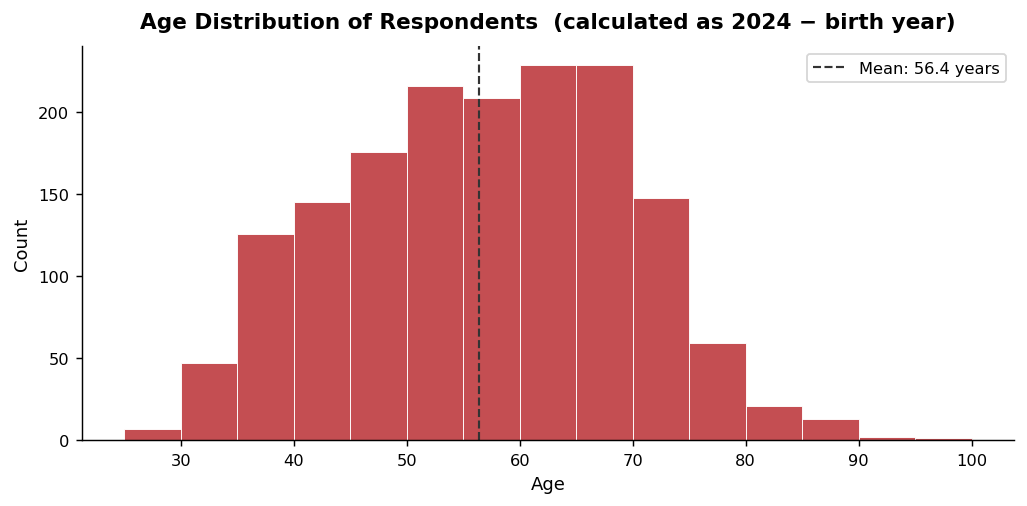

In [4]:
# ── 3b: Age distribution (birth year → age in 2024) ───────────────────────────
SURVEY_YEAR = 2024

ages = [SURVEY_YEAR - int(r["SOCIO_Age1"])
        for r in data if r.get("SOCIO_Age1") is not None]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=range(min(ages), max(ages) + 2, 5),
        color=C_SOCIO, edgecolor="white", linewidth=0.5)
ax.set_title(f"Age Distribution of Respondents  (calculated as {SURVEY_YEAR} − birth year)", pad=10)
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.axvline(np.mean(ages), color="#333", linestyle="--", linewidth=1.2,
           label=f"Mean: {np.mean(ages):.1f} years")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

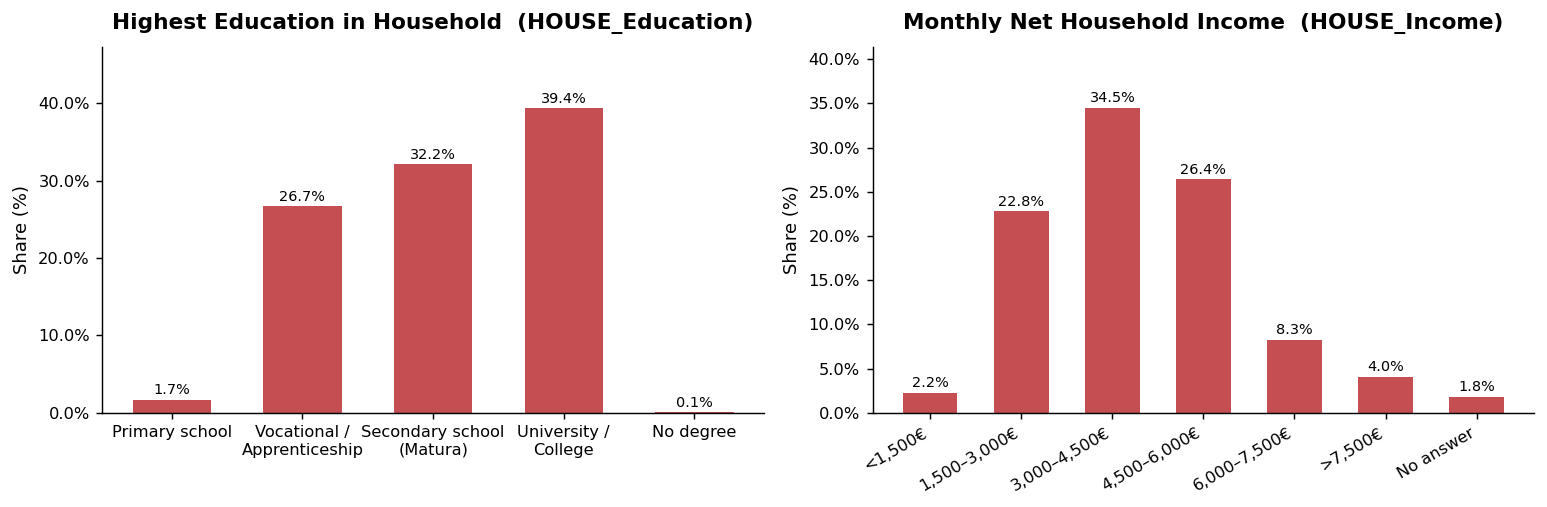

In [5]:
# ── 3c: Education & Income (side by side) ─────────────────────────────────────
edu_map = {
    "1": "Primary school",
    "2": "Vocational /\nApprenticeship",
    "3": "Secondary school\n(Matura)",
    "4": "University /\nCollege",
    "5": "No degree",
}

inc_map = {
    "1": "<1,500€",
    "2": "1,500–3,000€",
    "3": "3,000–4,500€",
    "4": "4,500–6,000€",
    "5": "6,000–7,500€",
    "6": ">7,500€",
    "7": "No answer",
}

edu_raw  = Counter(get_field("HOUSE_Education"))
inc_raw  = Counter(get_field("HOUSE_Income"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Education
e_keys  = sorted(edu_raw, key=int)
e_vals  = [edu_raw[k] for k in e_keys]
e_lbl   = [edu_map[k] for k in e_keys]
e_pcts  = pct_of(e_vals)
bars = axes[0].bar(e_lbl, e_pcts, color=C_SOCIO, width=0.6)
axes[0].set_title("Highest Education in Household  (HOUSE_Education)", pad=10)
axes[0].set_ylabel("Share (%)")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, max(e_pcts) * 1.2)
for bar, pct in zip(bars, e_pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

# Income
i_keys  = sorted(inc_raw, key=int)
i_vals  = [inc_raw[k] for k in i_keys]
i_lbl   = [inc_map.get(k, k) for k in i_keys]
i_pcts  = pct_of(i_vals)
bars = axes[1].bar(i_lbl, i_pcts, color=C_SOCIO, width=0.6)
axes[1].set_title("Monthly Net Household Income  (HOUSE_Income)", pad=10)
axes[1].set_ylabel("Share (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, max(i_pcts) * 1.2)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
for bar, pct in zip(bars, i_pcts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()